In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [3]:
df = pd.read_csv("dataset.csv", encoding='latin1')  # download from given link
df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


In [4]:
df = df.drop(columns=['emotion_in_tweet_is_directed_at'], errors='ignore')

In [5]:
df = df.dropna()

In [6]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)
    return text

df['clean_text'] = df['tweet_text'].apply(clean_text)

In [8]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['is_there_an_emotion_directed_at_a_brand_or_product'])

In [9]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['clean_text'])

X = tokenizer.texts_to_sequences(df['clean_text'])
X = pad_sequences(X, maxlen=50)

y = df['label']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
model = Sequential()
model.add(Embedding(input_dim=5000, output_dim=64, input_length=50))
model.add(SimpleRNN(64))
model.add(Dense(32, activation='relu'))
model.add(Dense(4, activation='softmax'))  # 4 classes

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/5
228/228 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.5933 - loss: 0.9251 - val_accuracy: 0.6042 - val_loss: 0.8895
Epoch 2/5
228/228 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.6904 - loss: 0.7521 - val_accuracy: 0.6003 - val_loss: 0.9120
Epoch 3/5
228/228 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8105 - loss: 0.5136 - val_accuracy: 0.5915 - val_loss: 1.0001
Epoch 4/5
228/228 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8735 - loss: 0.3598 - val_accuracy: 0.5849 - val_loss: 1.1870
Epoch 5/5
228/228 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.8983 - loss: 0.2795 - val_accuracy: 0.5833 - val_loss: 1.2605


In [13]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Accuracy:", accuracy)

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5833 - loss: 1.2605
Accuracy: 0.5832875370979309


In [14]:
model_lstm = Sequential()
model_lstm.add(Embedding(input_dim=5000, output_dim=64, input_length=50))
model_lstm.add(LSTM(64))
model_lstm.add(Dense(32, activation='relu'))
model_lstm.add(Dense(4, activation='softmax'))

model_lstm.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_lstm.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/5
228/228 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.5973 - loss: 0.9273 - val_accuracy: 0.6058 - val_loss: 0.8700
Epoch 2/5
228/228 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.6785 - loss: 0.7767 - val_accuracy: 0.6548 - val_loss: 0.8339
Epoch 3/5
228/228 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.7595 - loss: 0.6160 - val_accuracy: 0.6630 - val_loss: 0.8573
Epoch 4/5
228/228 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.8035 - loss: 0.5085 - val_accuracy: 0.6773 - val_loss: 0.8667
Epoch 5/5
228/228 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.8340 - loss: 0.4374 - val_accuracy: 0.6707 - val_loss: 0.9596


In [15]:
sample = ["I love my new iPhone"]
sample = tokenizer.texts_to_sequences(sample)
sample = pad_sequences(sample, maxlen=50)

prediction = model_lstm.predict(sample)
print(le.inverse_transform([np.argmax(prediction)]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
['Positive emotion']


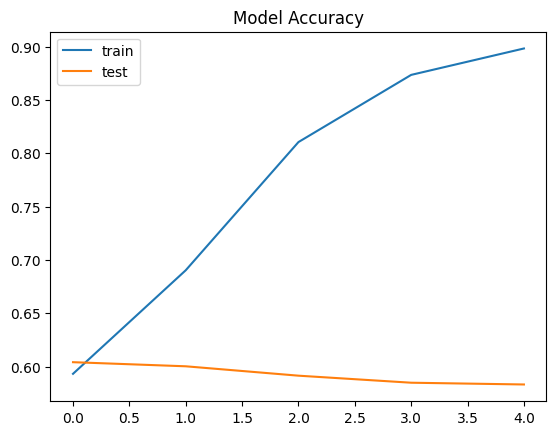

In [16]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='test')
plt.legend()
plt.title("Model Accuracy")
plt.show()